In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
inventory_df = pd.read_csv("inventory_df.csv")

inventory_df.head()

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point,inventory_status
0,0,30.678930,30.870992,6.704495,963,923.001639,2,10.0,10.0,2.0,282,631,Overstock
1,1,32.153846,32.134774,8.103550,581,386.001639,6,6.0,6.0,4.0,213,428,Optimal
2,2,25.946488,26.043583,7.373803,395,223.630401,5,5.0,5.0,2.0,108,259,Overstock
3,3,28.989967,29.032282,7.178213,375,476.531973,5,5.0,5.0,2.0,113,274,Optimal
4,4,34.749164,34.887731,7.069214,339,578.502977,7,5.0,5.0,4.0,160,353,Reorder


In [3]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku_id                 40 non-null     int64  
 1   avg_actual_demand      40 non-null     float64
 2   avg_predicted_demand   40 non-null     float64
 3   demand_std             40 non-null     float64
 4   current_stock          40 non-null     int64  
 5   selling_price          40 non-null     float64
 6   supplier_id            40 non-null     int64  
 7   lead_time_days         40 non-null     float64
 8   avg_lead_time          40 non-null     float64
 9   lead_time_variability  40 non-null     float64
 10  safety_stock           40 non-null     int64  
 11  reorder_point          40 non-null     int64  
 12  inventory_status       40 non-null     object 
dtypes: float64(7), int64(5), object(1)
memory usage: 4.2+ KB


# ABC Analysis 
ABC analysis classifies products based on annual consumption value.

Annual Consumption Value = Annual Demand * Selling Price

In [8]:
inventory_df['annual_consumption_value']=(
    inventory_df['avg_predicted_demand']*365*inventory_df['selling_price']
)

In [9]:
inventory_df = inventory_df.sort_values(
    by="annual_consumption_value",
    ascending=False
)

In [10]:
inventory_df["cumulative_value"] = (
    inventory_df["annual_consumption_value"].cumsum()
)

inventory_df["cumulative_percentage"] = (
    inventory_df["cumulative_value"] /
    inventory_df["annual_consumption_value"].sum()
) * 100

In [11]:
def classify_abc(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

inventory_df["ABC_Class"] = (
    inventory_df["cumulative_percentage"]
    .apply(classify_abc)
)

In [12]:
inventory_df["ABC_Class"].value_counts()

ABC_Class
A    23
B    10
C     7
Name: count, dtype: int64

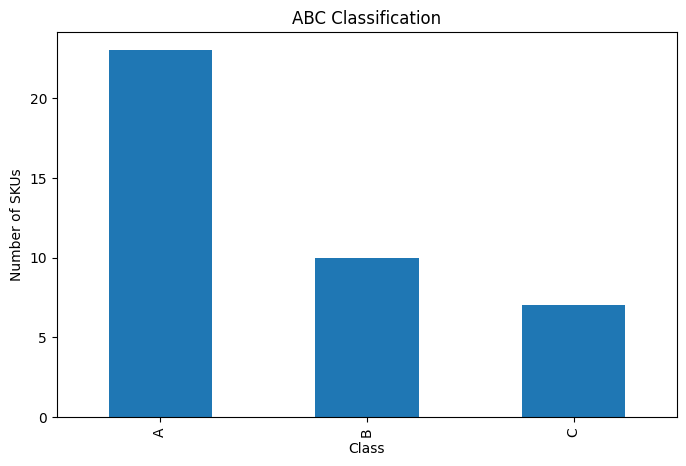

In [13]:
plt.figure(figsize=(8,5))

inventory_df["ABC_Class"].value_counts().plot(
    kind="bar"
)

plt.title("ABC Classification")
plt.xlabel("Class")
plt.ylabel("Number of SKUs")

plt.show()

# XYZ Analysis

XYZ Analysis classifies products based on demand variability.

Coefficient of Variation (CV):

CV = Demand Std / Average Demand

In [14]:
inventory_df["cv"] = (
    inventory_df["demand_std"] /
    inventory_df["avg_actual_demand"]
)

In [15]:
def classify_xyz(cv):

    if cv <= 0.25:
        return "X"

    elif cv <= 0.50:
        return "Y"

    else:
        return "Z"

inventory_df["XYZ_Class"] = (
    inventory_df["cv"]
    .apply(classify_xyz)
)

In [16]:
inventory_df["XYZ_Class"].value_counts()

XYZ_Class
X    28
Y    12
Name: count, dtype: int64

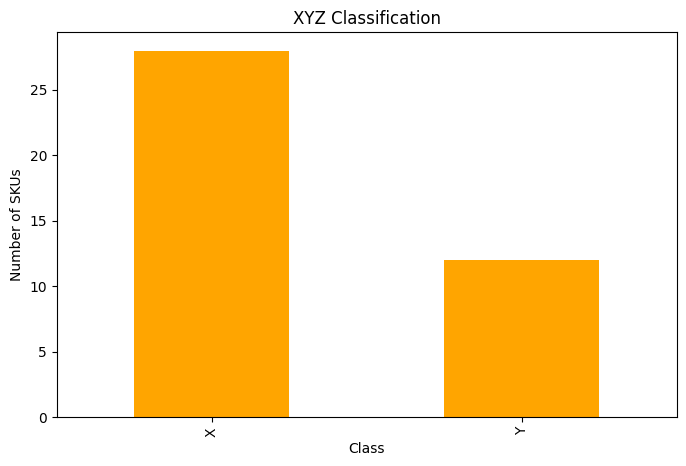

In [17]:
plt.figure(figsize=(8,5))

inventory_df["XYZ_Class"].value_counts().plot(
    kind="bar",
    color="orange"
)

plt.title("XYZ Classification")
plt.xlabel("Class")
plt.ylabel("Number of SKUs")

plt.show()

In [18]:
inventory_df["ABC_XYZ"] = (
    inventory_df["ABC_Class"] +
    inventory_df["XYZ_Class"]
)

In [19]:
inventory_df["ABC_XYZ"].value_counts()

ABC_XYZ
AX    18
BX     8
AY     5
CY     5
BY     2
CX     2
Name: count, dtype: int64

In [20]:
inventory_df["ABC_XYZ"].value_counts()

ABC_XYZ
AX    18
BX     8
AY     5
CY     5
BY     2
CX     2
Name: count, dtype: int64

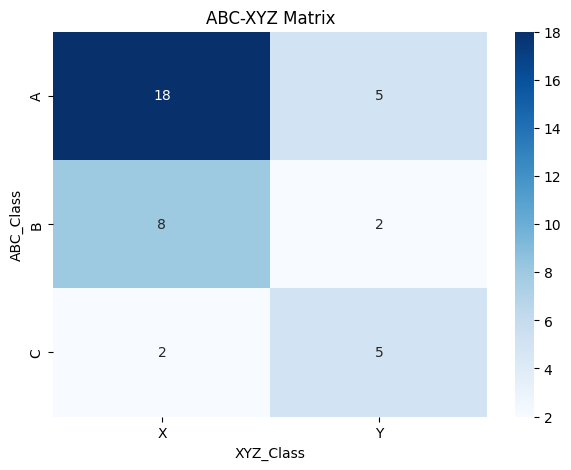

In [21]:
matrix = pd.crosstab(
    inventory_df["ABC_Class"],
    inventory_df["XYZ_Class"]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("ABC-XYZ Matrix")

plt.show()

In [22]:
inventory_df.sort_values(
    by="annual_consumption_value",
    ascending=False
).head(10)

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point,inventory_status,annual_consumptino_value,annual_consumption_value,cumulative_value,cumulative_percentage,ABC_Class,cv,XYZ_Class,ABC_XYZ
38,38,34.043478,34.133961,7.132127,1055,1831.211806,1,11.0,11.0,4.0,308,727,Optimal,2.281488e+07,2.281488e+07,2.281488e+07,6.107329,A,0.209501,X,AX
29,29,31.264214,31.293951,7.871904,494,1702.419699,5,5.0,5.0,2.0,128,304,Overstock,1.944554e+07,1.944554e+07,4.226041e+07,11.312717,A,0.251786,Y,AY
24,24,23.277592,23.430942,5.488842,776,2119.237224,2,10.0,10.0,2.0,322,593,Optimal,1.812434e+07,1.812434e+07,6.038475e+07,16.164434,A,0.235799,X,AX
39,39,29.729097,30.079778,5.737273,438,1638.972642,7,5.0,5.0,4.0,173,341,Optimal,1.799448e+07,1.799448e+07,7.837923e+07,20.981387,A,0.192985,X,AX
12,12,37.518395,37.570501,6.278398,710,1206.858395,8,7.0,7.0,4.0,352,641,Optimal,1.654993e+07,1.654993e+07,9.492916e+07,25.411648,A,0.167342,X,AX
26,26,27.428094,27.507713,5.607163,164,1620.715819,3,3.0,3.0,4.0,56,148,Optimal,1.627250e+07,1.627250e+07,1.112017e+08,29.767644,A,0.204431,X,AX
5,5,28.080268,28.150327,6.360552,496,1545.201405,8,7.0,7.0,4.0,277,497,Reorder,1.587674e+07,1.587674e+07,1.270784e+08,34.017700,A,0.226513,X,AX
22,22,30.511706,30.504150,7.364141,252,1176.487860,0,3.0,3.0,2.0,125,227,Optimal,1.309903e+07,1.309903e+07,1.401774e+08,37.524188,A,0.241355,X,AX
37,37,35.638796,35.480277,7.479500,536,994.817993,9,5.0,5.0,4.0,250,448,Optimal,1.288319e+07,1.288319e+07,1.530606e+08,40.972899,A,0.209870,X,AX
14,14,26.892977,27.034113,6.728826,555,1195.825084,6,6.0,6.0,4.0,180,365,Overstock,1.179975e+07,1.179975e+07,1.648604e+08,44.131580,A,0.250208,Y,AY


In [23]:
inventory_df.to_csv(
    "../data/processed/inventory_classified.csv",
    index=False
)